In [1]:
import sys
from pathlib import Path

# ------------------------------------------------------------------
# Descobre a raiz do projeto (pasta que contém ./src)
# Isso evita problemas de import dependendo de onde o notebook foi aberto.
# ------------------------------------------------------------------
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists():
            return candidate
    raise RuntimeError("Não foi possível localizar a raiz do projeto (pasta com ./src).")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_PATH = (PROJECT_ROOT / "src").resolve()

# Garante que src esteja no sys.path para imports como `discourses.*`
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from discourses._01_list_extract import list_extract
from discourses._02_discourses_extract import discourses_extract
from discourses._03_discourse_preprocessing import preprocessing
from discourses._04_topics import topics_main
from discourses._05_embeddings import generate_discourse_embeddings

# from _05_llm_analysis import llm_analysis

import pandas as pd
from gensim.models import LdaModel

import os
import shutil

def clear_dir_files(dir_path: Path) -> None:
    if not dir_path.exists():
        return
    for path in dir_path.iterdir():
        if path.is_file():
            path.unlink()

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)

/home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


PROJECT_ROOT: /home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis
SRC_PATH: /home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis/src


In [2]:
# teste de extração
# list_extract("02/07/2022", "05/07/2022")

In [3]:
# discursos antes da eleição
# df, name = preprocessing ( *discourses_extract ( *list_extract("02/07/2022", "29/10/2022") ) )

In [4]:
# discursos depois da eleição
# df, name = preprocessing ( *discourses_extract ( *list_extract("31/10/2022", "02/01/2023") ) )

## Testes para avaliação do threshold do parsing semântico

In [5]:
# Teste com discursos reais do CSV para ajustar o threshold + inspeção manual de chunks
csv_path = PROJECT_ROOT / "data" / "discourses" / "political_discourses_ini_31102022_fim_02012023.csv"
df_csv = pd.read_csv(csv_path)

# Mantém apenas discursos com texto disponível
df_csv = df_csv[df_csv["preprocess_disc"].notna()].copy()
df_csv = df_csv[df_csv["partido"].notna()].copy()

# Seleciona alguns discursos para inspeção rápida (2 por partido, até 6 no total)
sample_df = df_csv.groupby("partido", group_keys=False).head(2).head(6).copy()
print("Partidos no teste:", sorted(sample_df["partido"].astype(str).unique().tolist()))
print("Discursos no teste:", len(sample_df))

thresholds = [0.35, 0.45, 0.55]
results = []
inspection_data = {}  # guarda dados para inspeção manual por threshold

for threshold in thresholds:
    emb_df_test, emb_matrix_test, _ = generate_discourse_embeddings(
        dataframe=sample_df,
        party=None,
        text_col="raw_disc",
        similarity_threshold=threshold,
        min_sentences_per_chunk=1,
        max_sentences_per_chunk=None,
        save_files=False,
    )

    # Agrupa chunks por discurso para facilitar inspeção manual
    inspect_df = emb_df_test.sort_values(["source_index", "chunk_id"])
    inspect_df = inspect_df.groupby(["source_index", "partido", "parlamentar"], as_index=False)["chunk_text"].apply(list)
    inspect_df = inspect_df.rename(columns={"chunk_text": "chunks"})
    inspect_df["n_chunks"] = inspect_df["chunks"].apply(len)

    inspection_data[threshold] = {
        "emb_df": emb_df_test,
        "emb_matrix": emb_matrix_test,
        "inspect_df": inspect_df,
    }

    results.append({
        "threshold": threshold,
        "chunks_total": len(emb_df_test),
        "embedding_shape": emb_matrix_test.shape,
        "media_chunks_por_discurso": float(inspect_df["n_chunks"].mean()) if not inspect_df.empty else 0.0,
    })

    print("\nThreshold:", threshold)
    print("Quantidade total de chunks:", len(emb_df_test))
    print("Dimensão da matriz de embeddings:", emb_matrix_test.shape)
    display(inspect_df[["source_index", "partido", "parlamentar", "n_chunks"]])

# Resumo comparativo
results_df = pd.DataFrame(results)
display(results_df)

Partidos no teste: ['NOVO', 'PCdoB', 'PL', 'PT']
Discursos no teste: 6
...................................................
... Função generate_discourse_embeddings iniciada ...


/home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9072.96it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


... Total de chunks gerados: 58 ...


Batches: 100%|██████████| 2/2 [00:00<00:00,  2.27it/s]

... Função generate_discourse_embeddings encerrada ...
....................................................

Threshold: 0.35
Quantidade total de chunks: 58
Dimensão da matriz de embeddings: (58, 384)


...

... Total de chunks gerados: 116 ...


Batches: 100%|██████████| 4/4 [00:01<00:00,  3.49it/s]

... Função generate_discourse_embeddings encerrada ...
....................................................

Threshold: 0.55
Quantidade total de chunks: 116
Dimensão da matriz de embeddings: (116, 384)


,source_index,partido,parlamentar,n_chunks
0,0,NOVO,Marcel Van Hattem,18
1,1,PCdoB,Renildo Calheiros,15
2,2,PT,Reginaldo Lopes,8
3,3,NOVO,Marcel Van Hattem,11
4,4,PL,Bia Kicis,28
5,6,PT,Reginaldo Lopes,36


,threshold,chunks_total,embedding_shape,media_chunks_por_discurso
0,0.35,58,"(58, 384)",9.666667
1,0.45,91,"(91, 384)",15.166667
2,0.55,116,"(116, 384)",19.333333


In [6]:
results_df

,threshold,chunks_total,embedding_shape,media_chunks_por_discurso
0,0.35,58,"(58, 384)",9.666667
1,0.45,91,"(91, 384)",15.166667
2,0.55,116,"(116, 384)",19.333333


In [7]:

# ============================
# INSPEÇÃO MANUAL (ajuste aqui)
# ============================
threshold_to_inspect = 0.35

inspect_df = inspection_data[threshold_to_inspect]["inspect_df"]

print("\nInspeção manual para threshold:", threshold_to_inspect)
display(inspect_df[["source_index", "partido", "parlamentar", "n_chunks"]])

# escolha um discurso da tabela acima (source_index)
source_to_inspect = int(inspect_df.iloc[5]["source_index"])
row = inspect_df[inspect_df["source_index"] == source_to_inspect].iloc[0]

print("\nDiscurso selecionado:")
print("source_index:", row["source_index"])
print("partido:", row["partido"])
print("parlamentar:", row["parlamentar"])
print("n_chunks:", row["n_chunks"])

for i, chunk in enumerate(row["chunks"], start=1):
    print(f"\n--- Chunk {i} ---")
    print(chunk)


Inspeção manual para threshold: 0.35


,source_index,partido,parlamentar,n_chunks
0,0,NOVO,Marcel Van Hattem,3
1,1,PCdoB,Renildo Calheiros,5
2,2,PT,Reginaldo Lopes,6
3,3,NOVO,Marcel Van Hattem,5
4,4,PL,Bia Kicis,20
5,6,PT,Reginaldo Lopes,19



Discurso selecionado:
source_index: 6
partido: PT
parlamentar: Reginaldo Lopes
n_chunks: 19

--- Chunk 1 ---
O SR.

--- Chunk 2 ---
REGINALDO LOPES (PT - MG.

--- Chunk 3 ---
Como Líder. Sem revisão do orador.) - Vou falar como Líder do PT, Presidenta Bia Kicis. Quero cumprimentar os Deputados. Tive a oportunidade de ouvir também a despedida do Deputado conterrâneo Tiago Mitraud, que fez um excelente trabalho. Deputado, quero parabenizar V.Exa. pela dedicação ao Estado brasileiro, ao povo brasileiro. Vamos sentir sua falta aqui.

--- Chunk 4 ---
Volte sempre.

--- Chunk 5 ---
Também o Deputado Paulo Ganime despediu-se aqui hoje.

--- Chunk 6 ---
Um foi candidato ao Governo do Rio, outro foi candidato a Vice-Presidente da República.

--- Chunk 7 ---
Então, quero aqui agradecer a convivência.

--- Chunk 8 ---
Quero também dizer que esse foi um ano importante, um ano de muito trabalho na Casa, um ano em que assumi a Liderança do meu partido.

--- Chunk 9 ---
Fizemos um planejamento no in

In [8]:

# ============================
# INSPEÇÃO MANUAL (ajuste aqui)
# ============================
threshold_to_inspect = 0.45

inspect_df = inspection_data[threshold_to_inspect]["inspect_df"]

print("\nInspeção manual para threshold:", threshold_to_inspect)
display(inspect_df[["source_index", "partido", "parlamentar", "n_chunks"]])

# escolha um discurso da tabela acima (source_index)
source_to_inspect = int(inspect_df.iloc[5]["source_index"])
row = inspect_df[inspect_df["source_index"] == source_to_inspect].iloc[0]

print("\nDiscurso selecionado:")
print("source_index:", row["source_index"])
print("partido:", row["partido"])
print("parlamentar:", row["parlamentar"])
print("n_chunks:", row["n_chunks"])

for i, chunk in enumerate(row["chunks"], start=1):
    print(f"\n--- Chunk {i} ---")
    print(chunk)


Inspeção manual para threshold: 0.45


,source_index,partido,parlamentar,n_chunks
0,0,NOVO,Marcel Van Hattem,10
1,1,PCdoB,Renildo Calheiros,12
2,2,PT,Reginaldo Lopes,7
3,3,NOVO,Marcel Van Hattem,8
4,4,PL,Bia Kicis,26
5,6,PT,Reginaldo Lopes,28



Discurso selecionado:
source_index: 6
partido: PT
parlamentar: Reginaldo Lopes
n_chunks: 28

--- Chunk 1 ---
O SR.

--- Chunk 2 ---
REGINALDO LOPES (PT - MG.

--- Chunk 3 ---
Como Líder. Sem revisão do orador.) - Vou falar como Líder do PT, Presidenta Bia Kicis. Quero cumprimentar os Deputados. Tive a oportunidade de ouvir também a despedida do Deputado conterrâneo Tiago Mitraud, que fez um excelente trabalho. Deputado, quero parabenizar V.Exa.

--- Chunk 4 ---
pela dedicação ao Estado brasileiro, ao povo brasileiro.

--- Chunk 5 ---
Vamos sentir sua falta aqui.

--- Chunk 6 ---
Volte sempre.

--- Chunk 7 ---
Também o Deputado Paulo Ganime despediu-se aqui hoje.

--- Chunk 8 ---
Um foi candidato ao Governo do Rio, outro foi candidato a Vice-Presidente da República.

--- Chunk 9 ---
Então, quero aqui agradecer a convivência.

--- Chunk 10 ---
Quero também dizer que esse foi um ano importante, um ano de muito trabalho na Casa, um ano em que assumi a Liderança do meu partido.

--- Chunk 

## Execução da geração de embeddings

In [9]:
# antes da eleição
csv_path_antes = PROJECT_ROOT / "data" / "discourses" / "political_discourses_ini_02072022_fim_29102022.csv"

df_csv_antes = pd.read_csv(csv_path_antes)

In [10]:
party_name = "UNIAO"
embeddings_dir = PROJECT_ROOT / "data" / "discourses" / "embeddings" / "discourses" / party_name
clear_dir_files(embeddings_dir)

emb_df_test, emb_matrix_test, _ = generate_discourse_embeddings(
        dataframe=df_csv_antes,
        party=party_name,
        text_col="preprocess_disc",
        similarity_threshold=0.35,
        min_sentences_per_chunk=1,
        max_sentences_per_chunk=None,
        save_files=True,
        source_csv_name="political_discourses_ini_02072022_fim_29102022.csv"
)

...................................................
... Função generate_discourse_embeddings iniciada ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9189.12it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


... Nenhum discurso encontrado para os filtros informados ...


In [11]:
# depois da eleição
csv_path_depois = PROJECT_ROOT / "data" / "running_files" / "political_discourses_ini_31102022_fim_02012023.csv"
df_csv_depois = pd.read_csv(csv_path_depois)

FileNotFoundError: [Errno 2] No such file or directory: '/home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis/data/running_files/political_discourses_ini_31102022_fim_02012023.csv'

In [ ]:
party_name = "UNIÃO"
embeddings_dir = PROJECT_ROOT / "data" / "discourses" / "embeddings" / "discourses" / party_name
clear_dir_files(embeddings_dir)

emb_df_test, emb_matrix_test, _ = generate_discourse_embeddings(
        dataframe=df_csv_depois,
        party=party_name,
        text_col="preprocess_disc",
        similarity_threshold=0.35,
        min_sentences_per_chunk=1,
        max_sentences_per_chunk=None,
        save_files=True,
        source_csv_name="political_discourses_ini_31102022_fim_02012023.csv"
)

...................................................
... Função generate_discourse_embeddings iniciada ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1798.42it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


... Total de chunks gerados: 103 ...


Batches: 100%|██████████| 4/4 [00:04<00:00,  1.17s/it]


... Arquivo CSV salvo em: data/running_files/embeddings\discourses_embeddings_UNIÃO_ini_31102022_fim_02012023.csv ...
... Arquivo NPY salvo em: data/running_files/embeddings\discourses_embeddings_UNIÃO_ini_31102022_fim_02012023.npy ...
... Função generate_discourse_embeddings encerrada ...
....................................................


....................................
... Função topics_main iniciada! ...
... Partido: UNIÃO ...
... Total de discursos considerados: 117 ...
... Criando o dicionário e o corpus a partir do dataframe fornecido ...
... Identificando valor mais adequado de tópicos ...
...........................................
... Executando compute_coherence_values ...
... [1/14] Testando 2 tópicos ...
... [1/14] concluído em 0.7s ...
... [2/14] Testando 3 tópicos ...
... [2/14] concluído em 0.8s ...
... [3/14] Testando 4 tópicos ...
... [3/14] concluído em 0.8s ...
... [4/14] Testando 5 tópicos ...
... [4/14] concluído em 0.9s ...
... [5/14] Testando 6 tópicos ...
... [5/14] concluído em 1.0s ...
... [6/14] Testando 7 tópicos ...
... [6/14] concluído em 1.0s ...
... [7/14] Testando 8 tópicos ...
... [7/14] concluído em 1.1s ...
... [8/14] Testando 9 tópicos ...
... [8/14] concluído em 1.1s ...
... [9/14] Testando 10 tópicos ...
... [9/14] concluído em 1.2s ...
... [10/14] Testando 11 tópicos ...
... [

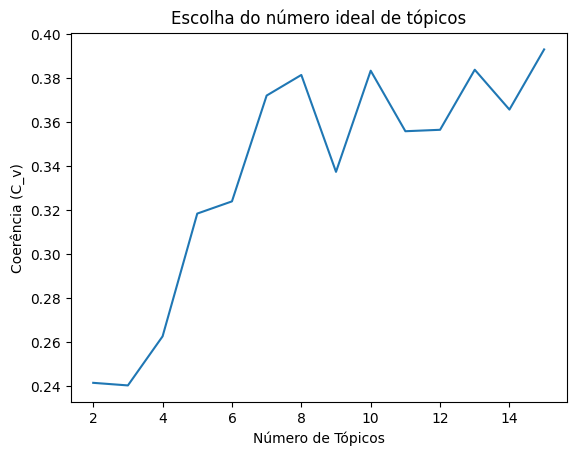

... A maior coerência identificada foi: 0.393 quando usando 15 tópicos! ...
... Treinando o modelo ...
... Função LDA_train iniciada! ...
Tópico 0: 0.008*"trabalhador" + 0.008*"todo" + 0.007*"brasileiro" + 0.005*"sr_presidente" + 0.005*"rural" + 0.005*"saber" + 0.005*"hoje" + 0.005*"país" + 0.004*"semana" + 0.004*"serviço"
Tópico 1: 0.011*"dinheiro" + 0.009*"energia" + 0.009*"veto" + 0.008*"todo" + 0.008*"governo" + 0.008*"vez" + 0.008*"redução" + 0.008*"real" + 0.007*"brasil" + 0.007*"alíquota"
Tópico 2: 0.013*"videogame" + 0.010*"game" + 0.009*"emprego" + 0.009*"indústria" + 0.008*"brasil" + 0.008*"jogo" + 0.008*"desenvolver" + 0.008*"renda" + 0.007*"gente" + 0.007*"dar"
Tópico 3: 0.015*"médico" + 0.011*"grande" + 0.009*"país" + 0.008*"brasil" + 0.008*"ano" + 0.008*"saúde" + 0.007*"bom" + 0.007*"todo" + 0.007*"real" + 0.007*"brasileiro"
Tópico 4: 0.014*"real" + 0.013*"governo" + 0.013*"dinheiro" + 0.012*"salário" + 0.010*"pobre" + 0.010*"todo" + 0.009*"inflação" + 0.008*"parlamentar"

,doc_id,topic,probability,preprocess_disc
1680,112,0,0.998691,união revisão orador sr_presidente bom dia s...
765,51,0,0.998659,união sp revisão orador sr_presidente usar est...
1725,115,0,0.998632,união mg revisão orador sr_presidente monte ...
900,60,0,0.998495,sr_presidente reportar hoje figura humano sing...
1650,110,0,0.995845,união rj revisão orador r_presidente apresent...
...,...,...,...,...
1409,93,14,0.999025,união sp questão ordem revisão orador apresent...
1109,73,14,0.998804,união sp questão ordem revisão orador apresent...
809,53,14,0.998788,união sp revisão orador sr_presidente efeito p...
839,55,14,0.997293,união sp ordem revisão orador união liberar ba...


In [ ]:
party_name = "UNIÃO"
topics_dir = PROJECT_ROOT / "data" / "discourses" / "topics" / party_name
clear_dir_files(topics_dir)

topics_main(df_csv_antes, party_name)

In [ ]:
# Gera embeddings dos termos dos topicos dos discursos (lda_topicos_termos.csv)
import json
import re
from sentence_transformers import SentenceTransformer

party_name = "UNIÃO"
# political-discourse-analysis/notebooks/discourse/data/discourses/lda_files/UNIÃO/lda_topicos_termos.csv
topics_terms_path = PROJECT_ROOT / "notebooks" / "discourse" / "data"/ "discourses" /"lda_files" / party_name / "lda_topicos_termos.csv"
# topics_terms_path= Path("../notebooks/discourse/data/discourses/lda_files/UNIÃO/lda_topicos_termos.csv")
discourse_topics_df = pd.read_csv(topics_terms_path)

def extract_terms(text: str) -> str:
    terms = re.findall(r"\"([^\"]+)\"", str(text))
    if terms:
        return " ".join(terms)
    cleaned = re.sub(r"\d+\.\d+\*", " ", str(text))
    return re.sub(r"\s+", " ", cleaned.replace("+", " ")).strip()

discourse_topics_df["terms_clean"] = discourse_topics_df["terms"].apply(extract_terms)
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)
discourse_embeddings = model.encode(discourse_topics_df["terms_clean"].tolist(), normalize_embeddings=True)
discourse_topics_df["embedding"] = [json.dumps(vec.tolist(), ensure_ascii=False) for vec in discourse_embeddings]

discourse_embeddings_dir = PROJECT_ROOT / "data" / "discourses" / "embeddings" / "discourses" / party_name
discourse_embeddings_dir.mkdir(parents=True, exist_ok=True)
discourse_embeddings_path = discourse_embeddings_dir / "topicos_embeddings_termos.csv"
discourse_topics_df.to_csv(discourse_embeddings_path, index=False, encoding="utf-8")

print("Embeddings de topicos dos discursos salvos em:", discourse_embeddings_path)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8924.53it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings de topicos dos discursos salvos em: /home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis/data/discourses/embeddings/discourses/UNIÃO/topicos_embeddings_termos.csv


In [15]:
# Calcula similaridade cosseno entre topicos dos discursos e topicos da pauta
import json  # carrega embeddings salvos
import numpy as np  # opera com matrizes
import pandas as pd  # manipula tabelas
from sentence_transformers import util  # calcula cosseno

party_name = "UNIAO"  # partido da pauta
party_name_discourse = "UNIÃO"  # partido dos discursos
agenda_topics_path = PROJECT_ROOT / "data" / "party_agenda" / "embeddings" / party_name / "topicos_embeddings_termos.csv"  # caminho pauta
discourse_topics_path = PROJECT_ROOT / "data" / "discourses" / "embeddings" / "discourses" / party_name_discourse / "topicos_embeddings_termos.csv"  # caminho discursos

agenda_topics_df = pd.read_csv(agenda_topics_path)  # le topicos da pauta
discourse_topics_df = pd.read_csv(discourse_topics_path)  # le topicos dos discursos

agenda_vecs = np.array([json.loads(v) for v in agenda_topics_df["embedding"]])  # vetoriza embeddings da pauta
discourse_vecs = np.array([json.loads(v) for v in discourse_topics_df["embedding"]])  # vetoriza embeddings dos discursos
sim_matrix = util.cos_sim(agenda_vecs, discourse_vecs).cpu().numpy()  # matriz de similaridade (agenda x discursos)

result_rows = []  # prepara linhas do resultado
for i in range(sim_matrix.shape[0]):  # percorre topicos da pauta
    for j in range(sim_matrix.shape[1]):  # percorre topicos dos discursos
        result_rows.append({
            "agenda_topic": int(agenda_topics_df.loc[i, "topic"]),
            "agenda_terms": agenda_topics_df.loc[i, "terms"],
            "discourse_topic": int(discourse_topics_df.loc[j, "topic"]),
            "discourse_terms": discourse_topics_df.loc[j, "terms"],
            "cosine_similarity": float(sim_matrix[i, j]),
        })  # adiciona linha para cada par

similarity_df = pd.DataFrame(result_rows)  # cria dataframe final
similarity_out = PROJECT_ROOT / "data" / "discourses" / "embeddings" / "discourses" / party_name_discourse / "topicos_similaridade_pauta.csv"  # saida csv
similarity_df.to_csv(similarity_out, index=False, encoding="utf-8")  # salva csv
print("Similaridade salva em:", similarity_out)  # mostra caminho

Similaridade salva em: /home/gpcmoura/Documents/Code/Msc/Repositories/political-discourse-analysis/data/discourses/embeddings/discourses/UNIÃO/topicos_similaridade_pauta.csv
